## Suppose that we have four observations, for which we compute a dissimilarity matrix. For instance, the dissimilarity between the first and second obser- vations is 0.3, and the dissimilarity between the second and fourth observations is 0.8.


In [1]:
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
import pandas as pd
dissimilarity = np.array([
    [0, 0.3, 0.4, 0.7],
    [0.3, 0, 0.5, 0.8],
    [0.4, 0.5, 0, 0.45],
    [0.7, 0.8, 0.45, 0]
])

condensed = squareform(dissimilarity)

### (a) On the basis of this dissimilarity matrix, sketch the dendrogram that results from hierarchically clustering these four observa- tions using complete linkage. Be sure to indicate on the plot the height at which each fusion occurs, as well as the observations corresponding to each leaf in the dendrogram.

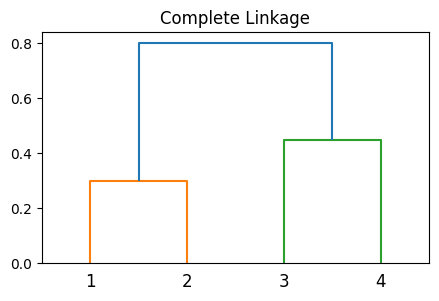

In [8]:
# 1. 每個樣本一開始是自己的群。

# 2. 找出距離最近的兩個群 → 合併。

# 3. 更新距離矩陣（看新的群和其他群的距離）。

# 4. 重複步驟 2–3，直到全合併完

Z_complete = linkage(condensed, method='complete')
plt.figure(figsize=(5,3))
dendrogram(Z_complete, labels=['1','2','3','4'])
plt.title("Complete Linkage")
plt.show()

### (b) Repeat (a), this time using single linkage clustering.

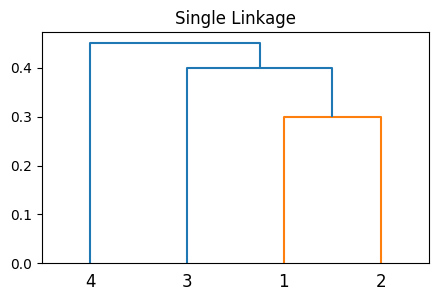

In [3]:
# 兩個群之間的距離取 最近 的兩點（min）
Z_single = linkage(condensed, method='single')
plt.figure(figsize=(5,3))
dendrogram(Z_single, labels=['1','2','3','4'])
plt.title("Single Linkage")
plt.show()

### (c) Suppose that we cut the dendrogram obtained in (a) such that two clusters result. Which observations are in each cluster?

### (d) Suppose that we cut the dendrogram obtained in (b) such that two clusters result. Which observations are in each cluster?

In [4]:
clusters_c = fcluster(Z_complete, t=2, criterion='maxclust')
clusters_s = fcluster(Z_single, t=2, criterion='maxclust')

In [5]:
obs = np.arange(1, len(clusters_c)+1)
df = pd.DataFrame({
    "Observation": obs,
    "Complete linkage": clusters_c,
    "Single linkage": clusters_s
})
print(df)

   Observation  Complete linkage  Single linkage
0            1                 1               1
1            2                 1               1
2            3                 2               1
3            4                 2               2


### (e) It is mentioned in this chapter that at each fusion in the den- drogram, the position of the two clusters being fused can be swapped without changing the meaning of the dendrogram. Draw a dendrogram that is equivalent to the dendrogram in (a), for which two or more of the leaves are repositioned, but for which the meaning of the dendrogram is the same.

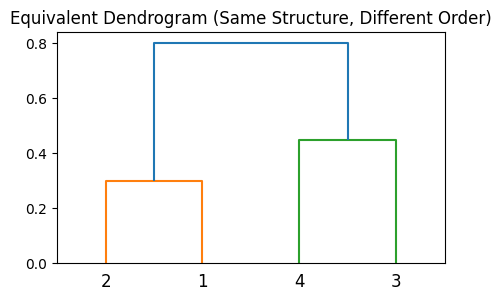

In [6]:
plt.figure(figsize=(5, 3))
dendrogram(Z_complete, labels=['2', '1', '4', '3'])
plt.title("Equivalent Dendrogram (Same Structure, Different Order)")
plt.show()